In [1]:
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os
from matplotlib.ticker import PercentFormatter

os.chdir('/home/amit.vaisman/other_papers_code/Diffusion-Compression-Editing-Attacks')

COLORS = {
    'jpeg': 'tab:blue',
    'turbo_ddcm': 'tab:orange',
    'robust_turbo_ddcm': 'tab:green',
    'ddcm': 'tab:red',
    'bpg': 'tab:purple',
    'robustB10': 'tab:brown',
    'diffc': 'tab:pink',
    'illm': 'tab:gray',
    'stable_codec': 'tab:cyan'
}

MARKERS = {
    'jpeg': 'o',
    'turbo_ddcm': 's',
    'robust_turbo_ddcm': 'D',
    'ddcm': '^',
    'bpg': 'v',
    'robustB10': 'P',
    'diffc': 'X',
    'illm': '*',
    'stable_codec': 'h'
}

LABELS = {'jpeg': 'JPEG', 'turbo_ddcm': 'Turbo-DDCM', 'robust_turbo_ddcm': 'Robust Turbo-DDCM', 'ddcm': 'DDCM', 'bpg': 'BPG', 'robustB10' : 'Robust Turbo-DDCM B=10', 'diffc' : 'DiffC', 'illm' : 'ILLM', 'VAE Bound' : 'VAE Bound', 'stable_codec' : 'StableCodec'}

SUBTITLES = {'psnr' : 'PSNR \\uparrow', 'lpips' : 'LPIPS \\downarrow', 'fid' : 'FID (log scale) \\downarrow',
             'niqe' : 'NIQE \\downarrow', 'failed_ind' : '\% Corrupted Files \\downarrow'}
DATASET_TITLES = {
    "dataset_Kodak24" : r"$\mathrm{Kodak24}_{512}$",
    "DIV2K_valid_HR_512" : r"$\mathrm{DIV2K}_{512}$",
}

DATASET_LEN = {
    "dataset_Kodak24" : 24,
    "DIV2K_valid_HR_512" : 100
}

VAE = {'dataset_Kodak24' : [26.43, 0.071, 20.271],
       'DIV2K_valid_HR_512' : [24.879, 0.0756, 23.404]}

plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams.update({
    'font.size': 16,          # base font size
    'axes.titlesize': 20,     # title size
    'axes.labelsize': 18,     # x and y label size
    'xtick.labelsize': 18,    # x tick size
    'ytick.labelsize': 18,    # y tick size
    'legend.fontsize': 18     # legend size
})

def tex_label(text: str) -> str:
    """Wrap plain text into LaTeX mathrm with escaped spaces."""
    return r"$\mathrm{" + text.replace(" ", r"\ ") + "}$"

In [2]:
# config
args = {}
args['methods'] = ['jpeg', 'bpg', 'illm', 'stable_codec', 'diffc', 'ddcm',  'turbo_ddcm', 'robust_turbo_ddcm']
args['datasets'] = ['dataset_Kodak24', 'DIV2K_valid_HR_512']
args['ber_min'] = 1e-6
args['ber_max'] = 1

NUM_TRIALS = 10
NUM_BER_VALUES = 6

In [3]:
results_df = pd.DataFrame()
for method in args['methods']:
    for dataset in args['datasets']:
        base = f'results/noisy_channel/{method}/{dataset}'

        current_df = pd.read_csv(f'{base}/noisy_channel_{method}.csv')

        # make sure all results are here
        # print(current_df.groupby(['ber', 'trial'])['image_file'].count().reset_index()['image_file'].unique())
        if current_df.groupby(['ber', 'trial'])['image_file'].count().reset_index()['image_file'].unique() != DATASET_LEN[dataset]:
            print(f"ERROR DATA: {method} {dataset}")

        if len(current_df) != DATASET_LEN[dataset] * (NUM_BER_VALUES * NUM_TRIALS + 1):
            print(f"ERROR DATA 2: {method} {dataset}")

        current_df_fid = pd.read_csv(f'{base}/fid_{method}.csv')
        if len(current_df_fid) != NUM_BER_VALUES * NUM_TRIALS:
            print(f"ERROR FID: {method} {dataset}")

        current_df = current_df.merge(current_df_fid, on=['ber', 'trial'], validate='m:1')

        assert (~((current_df['error'].notna()) & (current_df['psnr'].notna()))).all()
        current_df['failed_ind'] = current_df['error'].notna()

        current_df['dataset'] = dataset
        current_df['method'] = method
        results_df = pd.concat([results_df, current_df])

results_df = results_df.reset_index()
results_df = results_df[results_df['ber'].between(args['ber_min'], args['ber_max'])]
# results_df[['method', 'dataset']].drop_duplicates()

ERROR DATA: diffc dataset_Kodak24
ERROR DATA 2: diffc dataset_Kodak24


/tmp/ipykernel_4123105/3842972844.py:78: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


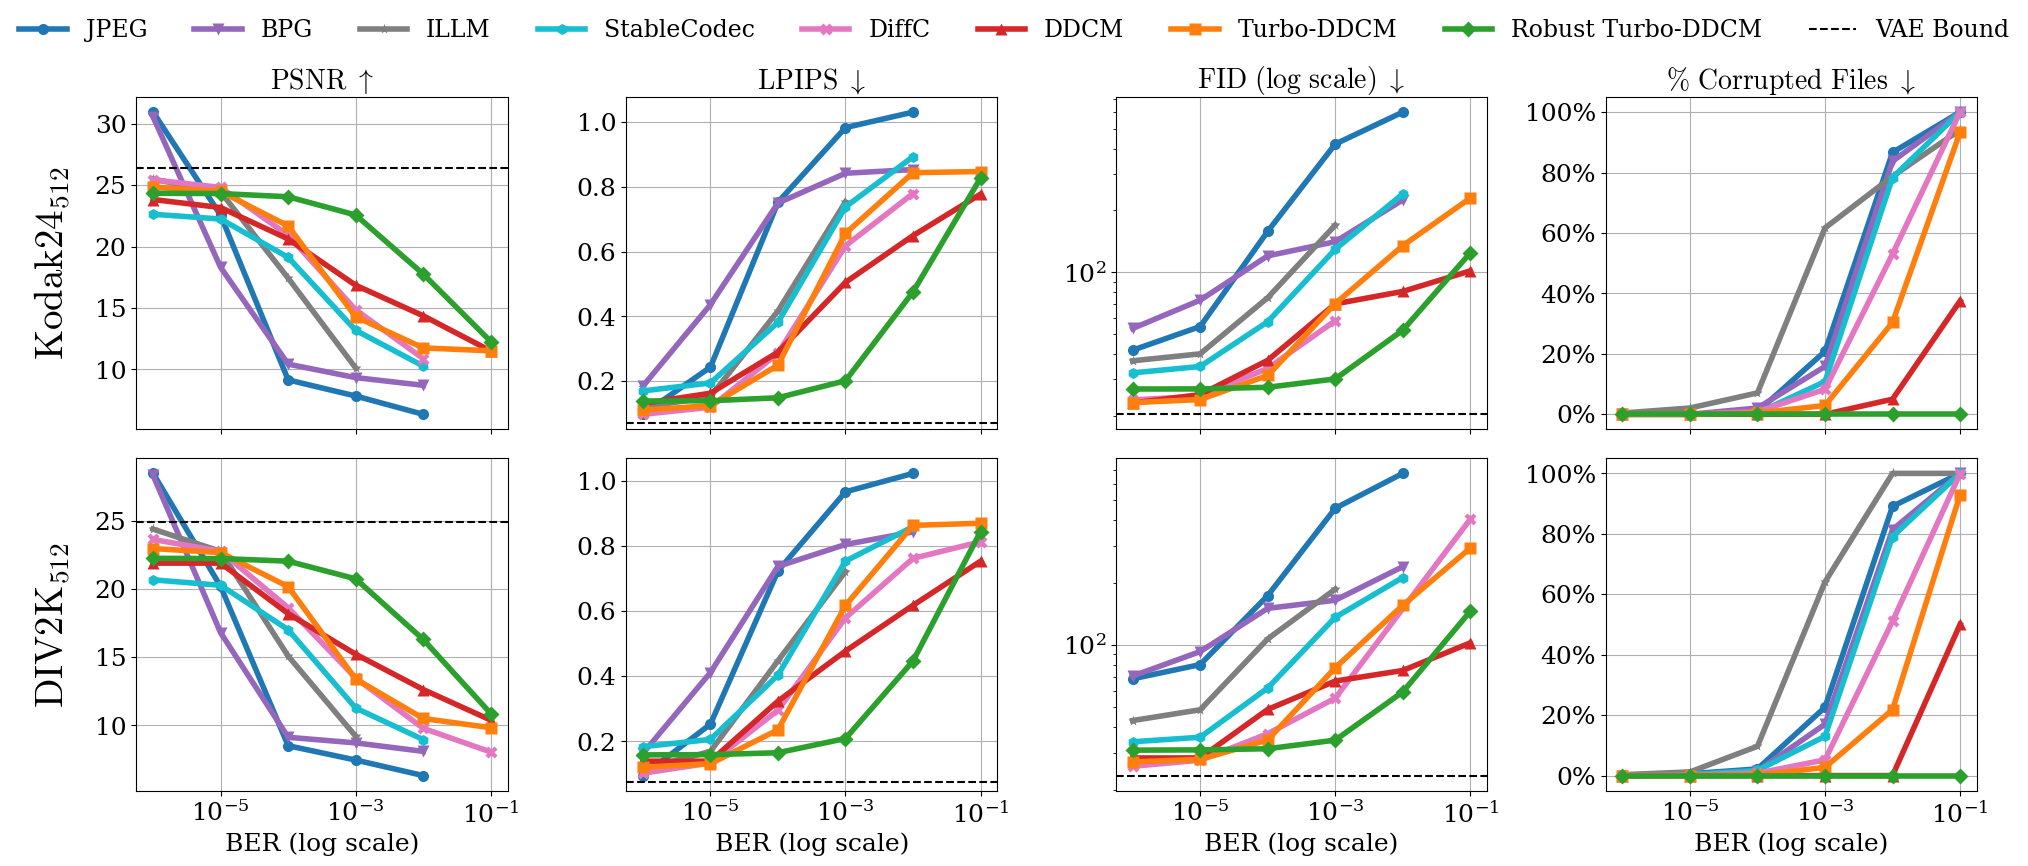

In [4]:
x_field = 'ber'
hue_field_name = 'method'
metrics_to_plot = ["psnr", "lpips", "fid", "failed_ind"]
datasets = args['datasets']
n_rows = len(datasets)
n_cols = len(metrics_to_plot)

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(5 * n_cols, 4.2 * n_rows),
                         sharex=True, constrained_layout=True)

if n_rows == 1:
    axes = [axes]
elif n_cols == 1:
    axes = [[ax] for ax in axes]

legend_ax = None
for row_idx, dataset in enumerate(datasets):
    df_subset = results_df[results_df["dataset"] == dataset]
    for col_idx, metric in enumerate(metrics_to_plot):
        ax = axes[row_idx][col_idx]

        sns.lineplot(
            data=df_subset,
            x=x_field,
            y=metric,
            hue=hue_field_name,
            marker='o',
            errorbar=None, # (ci_pi, confidence_level),
            ax=ax,
            style=hue_field_name,
            markers=MARKERS,
            dashes=False,
            palette=COLORS,
            linewidth=4,
            markersize=8,
            markeredgecolor="none"
        )

        if legend_ax is None:
            legend_ax = ax
        ax.get_legend().remove()

        ax.set_xscale('log')
        ax.grid(True)
        ax.set_ylabel(None)
        ax.set_xlabel('BER (log scale)')

        # Column titles on top row
        if row_idx == 0:
            ax.set_title(tex_label(SUBTITLES[metric]))
        if col_idx == 3:
            ax.yaxis.set_major_formatter(PercentFormatter(1.0))
        if col_idx < 3:
            ax.axhline(y=VAE[dataset][col_idx], color='black', linestyle='--', label='VAE Bound')
        if col_idx == 2:
            ax.set_yscale('log')

    axes[row_idx][0].text(-0.17, 0.5, DATASET_TITLES[dataset], va="center", ha="right",
                          fontsize=28, rotation=90, transform=axes[row_idx][0].transAxes)

handles, labels = legend_ax.get_legend_handles_labels()
labels = [LABELS[label] for label in labels]
desired_order = [LABELS[method] for method in (args['methods'] + ['VAE Bound'])]
order = [labels.index(l) for l in desired_order]

handles = [handles[i] for i in order]
labels = [labels[i] for i in order]

fig.legend(
    handles, labels,
    loc="upper center",
    ncol=len(labels),
    bbox_to_anchor=(0.5, 1.05),
    frameon=False,
    fontsize = 17
)

plt.tight_layout()
# plt.show()

output_dir = 'results/plots'
output_path = os.path.join(output_dir, 'quant_main.pdf')
plt.savefig(output_path, dpi=300, bbox_inches='tight')


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

K = 16384

def f(x):
    numerator = np.log2(K) * x + x
    denominator = math.log2(math.comb(K, x)) + x
    return numerator / denominator

def bpp(x):
    return 20*(math.log2(math.comb(K, x)) + x) / (512**2)

# x range (exclude 0 because denominator becomes 0)
x_vals = np.arange(1, 200)
y_vals = [f(x) for x in x_vals]
x_vals = [bpp(x) for x in x_vals]

# Plot
plt.figure()
plt.plot(x_vals, y_vals)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.title("Function plot for x in [1, 500]")
plt.show()